In [1]:
%matplotlib widget
# Boilerplate import code for all libraries
# Changes to the precision require re-loading the kernel and need to be done before any op uses them.
import argparse

import sphWarpCore_config as swc
from typing import Any
swc.configure(precision="float32", dim=Any) # precision: float16|half|float32|single|float64|double

import sphWarpCore as sph
from sphWarpCore.type_config import *
print(get_type_config()) # confirms active settings

# Initialize warp at this point
import warp as wp; wp.init()

import os
import torch
if torch.cuda.is_available(): # set the TORCH_CUDA_ARCH_LIST environment variable to the compute capability of the GPU for faster compiles
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm

# final import blocks that are generic
import matplotlib.pyplot as plt
from torch.profiler import profile, record_function, ProfilerActivity
import numpy as np
import math
import shlex    
import subprocess
import shutil

# custom SPH libraries
from integrators.integration import *
from sphWarpCore import *
from warpPlot import *

# This library
from warpSPH import *

# The case utilities that contain all the case setup functions for the various test cases
from warpSPH.caseUtils import *
import argparse
parser = argparse.ArgumentParser(description='Run the dam break simulation with obstacle.')

parser.add_argument('--nx', type=int, default=128, help='Number of particles along the x-axis')
parser.add_argument('--markerSize', type=int, default=8, help='Size of the markers in the plot')
parser.add_argument('--plotWidth', type=int, default=28, help='Width of the plot in inches')
parser.add_argument('--n_h', type=int, default=4, help='Target number of neighbors')
parser.add_argument('--L', type=float, default=2.0, help='Length of the domain')
parser.add_argument('--W', type=float, default=4.0, help='Width of the domain')
parser.add_argument('--fillRatio', type=float, default=0.25, help='Fill ratio for the domain')

parser.add_argument('--timeLimit', type=float, default=4.0, help='Time limit for the simulation')
parser.add_argument('--enableFreestream', action='store_true', help='Enable freestream boundary conditions')
parser.add_argument('--forcingWidth', type=float, default=2.0/16.0, help='Width of the forcing region')
parser.add_argument('--freeStreamVelocity', type=float, default=1.0, help='Velocity of the free stream')
parser.add_argument('--band', type=int, default=5, help='Number of particle bands around the domain for boundary conditions')

parser.add_argument('--targetDt', type=float, default=0.0005, help='Target timestep for the simulation')

parser.add_argument('--obstacleActive', action='store_true', help='If set, an obstacle will be included in the simulation')
parser.add_argument('--obstacleType', type=str, default='circle', help='Type of obstacle to include (none, circle, ellipse, box, roundedBox, equilateralTriangle, hexagon, horseshoe, star, nacaXXXX)')
parser.add_argument('--maxExtent', type=float, default=0.25, help='Maximum extent of the obstacle')
parser.add_argument('--aoa', type=float, default=0.0, help='Angle of attack of the obstacle in degrees')
parser.add_argument('--aspectRatio', type=float, default=1.0, help='Aspect ratio of the obstacle (for ellipse)')
parser.add_argument('--offsetX', type=float, default=-0.0, help='X offset of the obstacle')
parser.add_argument('--offsetY', type=float, default=0.0, help='Y offset of the obstacle')

parser.add_argument('--linearMotion', action='store_true', help='Enable linear motion of the obstacle')
parser.add_argument('--angularMotion', action='store_true', help='Enable angular motion of the obstacle')
# The motion can either be fixed, i.e., constantly spinning, or it can be a function of time, e.g., sinusoidal motion. The user can specify the type of motion using the --motionType argument.
parser.add_argument('--motionType', type=str, default='fixed', help='Type of motion for the obstacle (fixed, sinusoidal for now)')
parser.add_argument('--motionFrequency', type=float, default=1.0, help='Frequency of the motion for the obstacle')

parser.add_argument('--linearVelocityDirection', type=float, nargs=2, default=[0.0, 1.0], help='Direction of the linear motion (as a 2D vector)')
parser.add_argument('--linearVelocityMagnitude', type=float, default=0.5, help='Magnitude of the linear motion')
parser.add_argument('--angularVelocityMagnitude', type=float, default=1.0, help='Magnitude of the angular motion')

parser.add_argument('--caseName', type=str, default='4-open-flow', help='Name of the case to run (default: 12-dambreak)')
parser.add_argument('--plot', action='store_true', help='Enable plotting of the simulation results')
parser.add_argument('--plotInterval', type=int, default=10, help='Interval for plotting (default: 10)')

parser.add_argument('--bandWidth', type=float, default=16.0, help='Width of the band for the noise function')

cmd_args = '--plot --enableFreestream --timeLimit 5.0 --obstacleActive --offsetY -0.5 --maxExtent 0.125'
import shlex
    

args = parser.parse_args(shlex.split(cmd_args))

{'scalar_t': <class 'warp._src.types.float32'>, 'dim_t': typing.Any}
Warp 1.15.0 initialized:
   CUDA Toolkit 12.9, Driver 13.3
   Devices:
     "cpu"      : "CPU"
     "cuda:0"   : "NVIDIA GeForce RTX 3090" (24 GiB, sm_86, mempool enabled)
   Kernel cache:
     /home/veldora/.cache/warp/1.15.0


In [2]:

nx = args.nx
dim = 2
L = args.L
dx = L / nx
band = args.band
W = args.W
n_h = args.n_h
targetDt = args.targetDt


gamma = 5/3
rho0 = 1
nu_visc = 0.0005
freeSurface = True

timestamp = getCurrentTimestamp()
obstacleText = f'{args.obstacleType}_maxExtent{args.maxExtent}_aspectRatio{args.aspectRatio}_offsetX{args.offsetX}_offsetY{args.offsetY}'
motionText = f'linearMotion{args.linearMotion}_angularMotion{args.angularMotion}_motionType{args.motionType}_motionFrequency{args.motionFrequency}_linearVelocityDirection{args.linearVelocityDirection[0]}_{args.linearVelocityDirection[1]}_linearVelocityMagnitude{args.linearVelocityMagnitude}_angularVelocityMagnitude{args.angularVelocityMagnitude}'
caseName = f'{args.caseName}_{timestamp}_{nx}_{n_h}_{L}_{W}_{obstacleText}'

extraData = {
    'nx': nx,
    'dim': dim,
    'L': L,
    'n_h': n_h,

    'gamma': gamma,
    'rho0': rho0,
    'nu_visc': nu_visc,
}

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = get_torch_precision()


domain = buildDomainDescription(L + dx * (band) * 2, dim, True, device, dtype)
domain.min = torch.tensor([-W/2, -L/2 - dx * (band)], device = device, dtype = dtype)
domain.max = torch.tensor([W/2, L/2 + dx * (band)], device = device, dtype = dtype)
interiorDomain = buildDomainDescription(L, dim, False, device, dtype)
interiorDomain.min = torch.tensor([-W/2, -L/2], device = device, dtype = dtype)
interiorDomain.max = torch.tensor([W/2, L/2], device = device, dtype = dtype)


config, integrator = buildConfig(
    domain = domain,
    dim = dim,
    kernel = KernelFunctions.Wendland4,
    targetNeighbors = n_h_to_nH(4, dim),
    supportMode = SupportScheme.KernelMeanSymmetric,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta2,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = None,
    adaptiveDt = True,
    cflFactor=0.3,
)
config.nx = nx + band * 2
config.dx = dx

config.minDt = 1e-8
# config.dx = L / (nx * 2)

scheme = WeaklyCompressibleSPHScheme.deltaSPH
SimulationSystem, SimulationState, SimulationConfig, SimulationUpdate, fn, export_fn, import_fn = buildScheme(scheme)


schemeConfig = SimulationConfig()
schemeConfig.surfaceDetectionConfig.active = freeSurface
schemeConfig.bandwith = L / args.bandWidth / config.dx

schemeConfig.gravityConfig.active = True
schemeConfig.gravityConfig.type = GravityType.Directional
schemeConfig.gravityConfig.magnitude = 9.81
schemeConfig.gravityConfig.origin =[0.0, -1.0]

In [3]:

fluid_sdf = lambda x: sampleDomainSDF(x, domain, invert = True)


import copy
interiorDomain2 = copy.deepcopy(interiorDomain)
interiorDomain2.min[0] -= 20 * (band)
interiorDomain2.max[0] += 20 * (band)
domain_sdf = lambda x: sampleDomainSDF(x, interiorDomain2, invert = False)

# obstacleWidth = L/16
# obstacleHeight = L/4

fluidW = args.W
fluidH = args.L * args.fillRatio
box_sdf = lambda points: sampleSDF(points, operatorDict['translate'](lambda x: getSDF('box')['function'](x, torch.tensor([fluidW/2,fluidH/2]).to(points.device)), torch.tensor([0.0,interiorDomain.min[1] + fluidH/2]).to(points.device)), invert = False)


from warpSPH.utils.naca import *


maxExtent = args.maxExtent
aspectRatio = args.aspectRatio
offsetX = args.offsetX
offsetY = args.offsetY
aoa = args.aoa

from utils import buildObstacleSDF

obstacle_sdf = buildObstacleSDF(args.obstacleType, args.offsetX, args.offsetY, args.maxExtent, args.aspectRatio, aoa, config, schemeConfig, L, W)

# obstacle_sdf = 

regions = []

regions.append(buildRegion(config, schemeConfig, box_sdf, RegionType.Fluid, initialConditions = {}, shortEdge = W > L))
# regions.append(buildRegion(config, schemeConfig, domain_sdf, RegionType.Boundary, initialConditions = {}, kind = BCType.noSlip))
# if obstacle:

# bcType = BCType.noSlip
# if args.linearMotion or args.angularMotion:
bcType = BCType.constant
if args.obstacleActive:
    regions.append(buildRegion(config, schemeConfig, obstacle_sdf, RegionType.Boundary, initialConditions = {}, kind = bcType, shortEdge = W > L))
if args.band > 0:
    regions.append(buildRegion(config, schemeConfig, domain_sdf, RegionType.Boundary, initialConditions = {}, kind = BCType.noSlip, shortEdge = W > L))


# fluid_sdf = lambda x: sampleDomainSDF(x, domain, invert = True)
# regions = []

# regions.append(buildRegion(config, schemeConfig, fluid_sdf, RegionType.Fluid, initialConditions = {}))

for region in regions:
    region = filterRegion(region, regions)


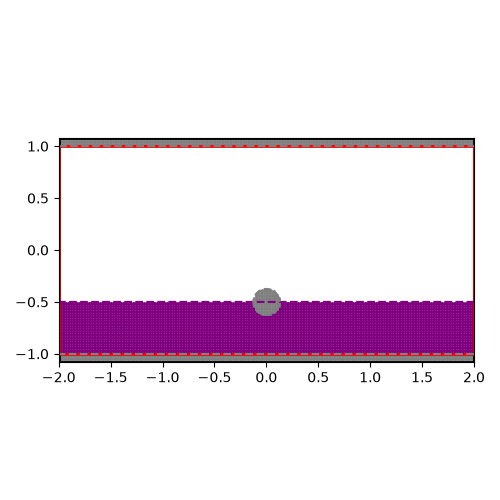

In [4]:
fig, axis = plt.subplots(1, 1, figsize=(5, 5), squeeze=False)
plotRegions(regions, axis[0,0], plotFluid = True, plotParticles = True)

rectangle = plt.Rectangle((domain.min[0].cpu().numpy(), domain.min[1].cpu().numpy()), domain.max[0].cpu().numpy() - domain.min[0].cpu().numpy(), domain.max[1].cpu().numpy() - domain.min[1].cpu().numpy(), fill=False, color='black', lw=2)
axis[0,0].add_patch(rectangle)

rectangleInterior = plt.Rectangle((interiorDomain.min[0].cpu().numpy(), interiorDomain.min[1].cpu().numpy()), interiorDomain.max[0].cpu().numpy() - interiorDomain.min[0].cpu().numpy(), interiorDomain.max[1].cpu().numpy() - interiorDomain.min[1].cpu().numpy(), fill=False, color='red', lw=2)
axis[0,0].add_patch(rectangleInterior)

import matplotlib.patches as patches

for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(domain.min[0].item(), domain.max[0].item())
    ax.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()

In [15]:

# compressibleSystem = setupBasicWeaklyCompressibleInitialState(nx, config, schemeConfig, SimulationState, SimulationSystem)
compressibleSystem = initializeWeaklyCompressibleSimulation(regions, config, schemeConfig, SimulationSystem, SimulationState, verbose = True)
# compressibleSystem.state.positions = shuffleParticles(compressibleSystem.state, config, schemeConfig, 32, jitterAmount = 0.1)

if args.enableFreestream:
    u_freestream = args.freeStreamVelocity
    forcingWidth = args.forcingWidth
    print("Enabling freestream boundary conditions (forcing width: {}, freestream velocity: {})".format(forcingWidth, u_freestream))

    forcingSDF = lambda points: sampleSDF(points, lambda x: getSDF('box')['function'](x, torch.tensor([W/2 - forcingWidth, L/2]).to(points.device)), invert = True)

    def ldcDirichlet(state, cfg, schemeCfg, positions, d, n, t, dt):
        velocities = state.velocities.clone()
        # mask = torch.logical_or(positions[:,0] < -W/2 + forcingWidth, positions[:,0] > W/2 - forcingWidth)
        velocities[:,0] = u_freestream * 2
        # v_diff = u_freestream - state.velocities[:,0]
        # # slowly ramp the velocities to the target velocity over time
        # velocities[:,0] = state.velocities[:,0] + v_diff * dt / 0.1
        return velocities

    def ldcDirichletDensity(state, cfg, schemeCfg, positions, d, n, t, dt):
        densities = state.densities.clone()
        densities[:] = rho0
        # ramp the densities to the target density over time
        densities[:] = state.densities[:] + (rho0 - state.densities[:]) * dt / 0.1
        return densities

    def ldcDirichletUpdate(state, cfg, schemeCfg, positions, d, n, t, dt):
        velocities = torch.zeros_like(state.velocities)
        mask = torch.logical_or(positions[:,0] < -W/2 + forcingWidth, positions[:,0] > W/2 - forcingWidth)
        velocities[:,0] = torch.where(mask, 0.0, velocities[:,0])
        return velocities

    def ldcDirichletUpdateDensity(state, cfg, schemeCfg, positions, d, n, t, dt):
        densities = torch.zeros_like(state.densities)
        mask = torch.logical_or(positions[:,0] < -W/2 + forcingWidth, positions[:,0] > W/2 - forcingWidth)
        densities[:] = torch.where(mask, 0.0, densities[:])
        return densities

    def ldcForcing(state, cfg, schemeCfg, positions, d, n, t, dt):
        forcing = torch.zeros_like(state.velocities)
        mask = torch.logical_or(positions[:,0] < -W/2 + forcingWidth, positions[:,0] > W/2 - forcingWidth)
        velocities = state.velocities.clone()
        velocities[:,0] = u_freestream
        # print("Forcing velocities: ", velocities[mask], 'dt: ', dt)
        v_diff = u_freestream - state.velocities[:,0]
        # slowly ramp the velocities to the target velocity over time
        # print("v_diff: ", v_diff, "dt: ", dt, "v_diff * dt / 0.1: ", v_diff * dt / 0.1)
        velocities[:,0] = state.velocities[:,0] + v_diff * dt / 0.1

        forcing[:,0] = v_diff * dt / 0.1




        return forcing

    ldcBC = BoundaryCondition(
        type = BoundaryConditionType.dynamic,
        sdf = forcingSDF,
        dirichletFunctions = {
            # 'velocities': lambda state, cfg, schemeCfg, positions, d, n, t, dt: ldcDirichlet(state, cfg, schemeCfg, positions, d, n, t, dt),
            # 'densities': lambda state, cfg, schemeCfg, positions, d, n, t, dt: ldcDirichletDensity(state, cfg, schemeCfg, positions, d, n, t, dt)
        },
        updateFunctions = {
            # 'dvdt': lambda state, cfg, schemeCfg, positions, d, n, t, dt: ldcDirichletUpdate(state, cfg, schemeCfg, positions, d, n, t, dt),
            # 'drhodt': lambda state, cfg, schemeCfg, positions, d, n, t, dt: ldcDirichletUpdateDensity(state, cfg, schemeCfg, positions, d, n, t, dt)
        },
        forcingFunctions = [ldcForcing]

    )
    schemeConfig.boundaryConditions = [ldcBC]
    minBoundaryDistance = torch.ones_like(compressibleSystem.state.positions[:,0]) * np.inf
    for region in regions:
        if region.type == RegionType.Boundary:
            distances = region.sdf(compressibleSystem.state.positions)[0]
            minBoundaryDistance = torch.min(minBoundaryDistance, distances)
    maxDistance = compressibleSystem.state.supports.max() * 2.0
    minBoundaryDistance = torch.clamp(minBoundaryDistance, min=0.0, max = maxDistance)
    ramp = (minBoundaryDistance) / maxDistance
    def rampFn(r):
        ramped = 15/8 * r - 10/8 * r**3 + 3/8 * r**5
        return torch.clamp(ramped, min=0.0, max = 1.0)
    ramped = rampFn(ramp)

    compressibleSystem.state.velocities[compressibleSystem.state.kinds == 0,0] += u_freestream * ramped[compressibleSystem.state.kinds == 0]




Enabling freestream boundary conditions (forcing width: 0.125, freestream velocity: 1.0)


In [16]:

schemeConfig.fluid.fixedSoundSpeed, config.dt = setupWeaklyCompressibleTimestep(config, schemeConfig, compressibleSystem, targetDt, verbose = True)

currentSystem = compressibleSystem
forcing = computeForcing(currentSystem, config.dt, currentSystem.t, config, schemeConfig)

Computed c0: 17.271244667215353, target c0: 17.271244667215353, diff: 0.0
Computed dt: 0.0005, target dt: 0.0005, diff: 0.0
Max velocity: 1.0, CFL: 0.03200000151991844, Max Mach: 0.057899706065654755


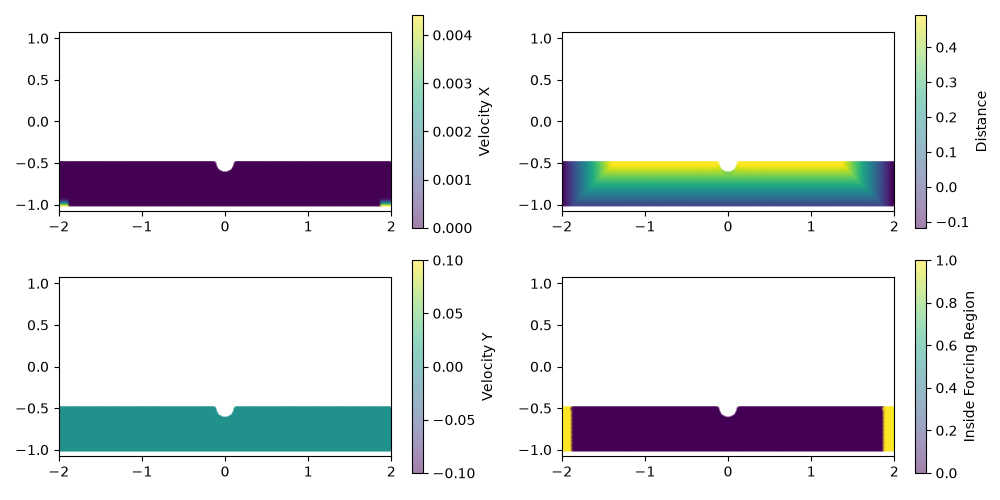

In [22]:
fig, axis = plt.subplots(2, 2, figsize=(10, 5), squeeze=False)

mask = currentSystem.state.kinds == 0

sc = axis[0,0].scatter(currentSystem.state.positions[mask,0].cpu().numpy(), currentSystem.state.positions[mask,1].cpu().numpy(), s=args.markerSize, c=forcing[mask,0].cpu().numpy(), cmap='viridis', alpha=0.5)
fig.colorbar(sc, ax=axis[0,0], label='Velocity X')
sc = axis[1,0].scatter(currentSystem.state.positions[mask,0].cpu().numpy(), currentSystem.state.positions[mask,1].cpu().numpy(), s=args.markerSize, c=forcing[mask,1].cpu().numpy(), cmap='viridis', alpha=0.5)
fig.colorbar(sc, ax=axis[1,0], label='Velocity Y')


dist = forcingSDF(currentSystem.state.positions)[0]
sc = axis[0,1].scatter(currentSystem.state.positions[mask,0].cpu().numpy(), currentSystem.state.positions[mask,1].cpu().numpy(), s=args.markerSize, c=dist[mask].cpu().numpy(), cmap='viridis', alpha=0.5)
fig.colorbar(sc, ax=axis[0,1], label='Distance')

distMask = dist < 0.0
sc = axis[1,1].scatter(currentSystem.state.positions[mask,0].cpu().numpy(), currentSystem.state.positions[mask,1].cpu().numpy(), s=args.markerSize, c=distMask[mask].cpu().numpy(), cmap='viridis', alpha=0.5)
fig.colorbar(sc, ax=axis[1,1], label='Inside Forcing Region')

for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(domain.min[0].item(), domain.max[0].item())
    ax.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()

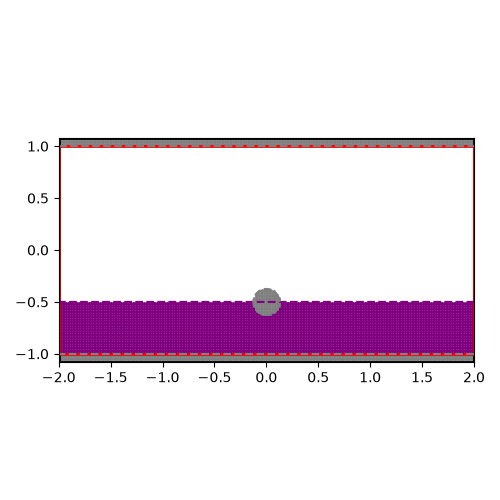

In [17]:
fig, axis = plt.subplots(1, 1, figsize=(5, 5), squeeze=False)
plotRegions(regions, axis[0,0], plotFluid = True, plotParticles = True)

rectangle = plt.Rectangle((domain.min[0].cpu().numpy(), domain.min[1].cpu().numpy()), domain.max[0].cpu().numpy() - domain.min[0].cpu().numpy(), domain.max[1].cpu().numpy() - domain.min[1].cpu().numpy(), fill=False, color='black', lw=2)
axis[0,0].add_patch(rectangle)

rectangleInterior = plt.Rectangle((interiorDomain.min[0].cpu().numpy(), interiorDomain.min[1].cpu().numpy()), interiorDomain.max[0].cpu().numpy() - interiorDomain.min[0].cpu().numpy(), interiorDomain.max[1].cpu().numpy() - interiorDomain.min[1].cpu().numpy(), fill=False, color='red', lw=2)
axis[0,0].add_patch(rectangleInterior)

import matplotlib.patches as patches

for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(domain.min[0].item(), domain.max[0].item())
    ax.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()

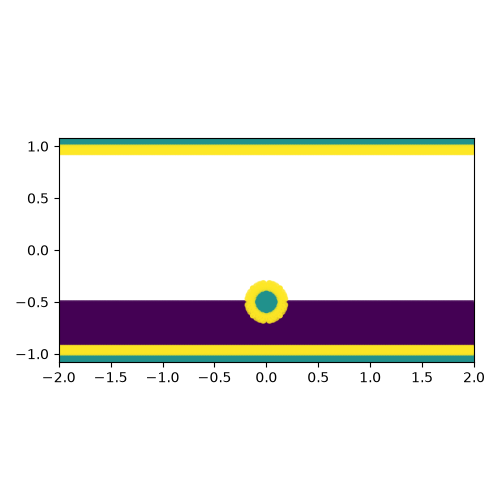

In [7]:
fig, axis = plt.subplots(1, 1, figsize=(5, 5), squeeze=False)

axis[0,0].scatter(compressibleSystem.state.positions[:,0].cpu().numpy(), compressibleSystem.state.positions[:,1].cpu().numpy(), s=args.markerSize, c=compressibleSystem.state.kinds.cpu().numpy
(), cmap='viridis', alpha=0.5)

for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(domain.min[0].item(), domain.max[0].item())
    ax.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()

In [8]:
# compressibleSystem = initializeWeaklyCompressibleSimulation(regions, config, schemeConfig, SimulationSystem, SimulationState, verbose = True)

# compressibleSystem.state.positions = shuffleParticles(compressibleSystem.state, config, schemeConfig, 128, jitterAmount = 1.0)


schemeConfig.fluid.fixedSoundSpeed, config.dt = setupWeaklyCompressibleTimestep(config, schemeConfig, compressibleSystem, targetDt, verbose = True)
print(f"Computed timestep: {config.dt:.6g}, target timestep: {targetDt:.6g}, diff: {abs(config.dt - targetDt):.6g}")

Computed c0: 17.271244667215353, target c0: 10.0, diff: 7.271244667215353
Computed dt: 0.0005, target dt: 0.0005, diff: 0.0
Max velocity: 1.0, CFL: 0.03200000151991844, Max Mach: 0.057899706065654755
Computed timestep: 0.0005, target timestep: 0.0005, diff: 0


In [9]:

# t = torch.tensor(0, device = device, dtype = dtype)
# linearVelocity = 0.5 * torch.cos(t * np.pi * 2)

# config.rigidBodies[0].linearVelocity = 0.0
# schemeConfig.rigidBodies = config.rigidBodies

In [10]:
# def ldcDirichlet(state, cfg, schemeCfg, positions, d, n, t, dt):
#     velocities = state.velocities.clone()
#     velocities[:,0] = torch.where(positions[:,1] > 1.0, 1.0, velocities[:,0])
#     return velocities

# ldcBC = BoundaryCondition(
#     type = BoundaryConditionType.dynamic,
#     sdf = lambda x: fluid_sdf(x),
#     dirichletFunctions = {
#         'velocities': lambda state, cfg, schemeCfg, positions, d, n, t, dt: ldcDirichlet(state, cfg, schemeCfg, positions, d, n, t, dt)
#     }
# )
# schemeConfig.boundaryConditions = [ldcBC]


# enforceDirichlet(compressibleSystem, compressibleSystem.t, config.dt, config, schemeConfig)

In [11]:
# display(schemeConfig.shiftProperties)
# schemeConfig.shiftProperties.summationDensity = False
# schemeConfig.shiftProperties.active = True
# schemeConfig.shiftProperties.reuseNormals = True

In [12]:
runningState = compressibleSystem.initializeNewState()

caseName = 'openFlow'
exportPath = prepExport(f'{caseName}', config, schemeConfig, scheme, export_fn)
exportSimulationSystem(exportPath, 'initialState', scheme, compressibleSystem, exportAdjacency = False, stages = None, exportStagesAdjacency = False, extraData = dict({
    'frame_num': 0,
}, **extraData))

In [13]:

adjacency = buildVerletList(
    runningState.state, 
    config.domain, verletScale = 1.0, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = None,
    verbose = False)
# currentSystem.adjacency = adjacency

Module sphWarpCore.radiusSearch.wp_compactHash a87b46c load on device 'cuda:0' took 3.03 ms  (cached)


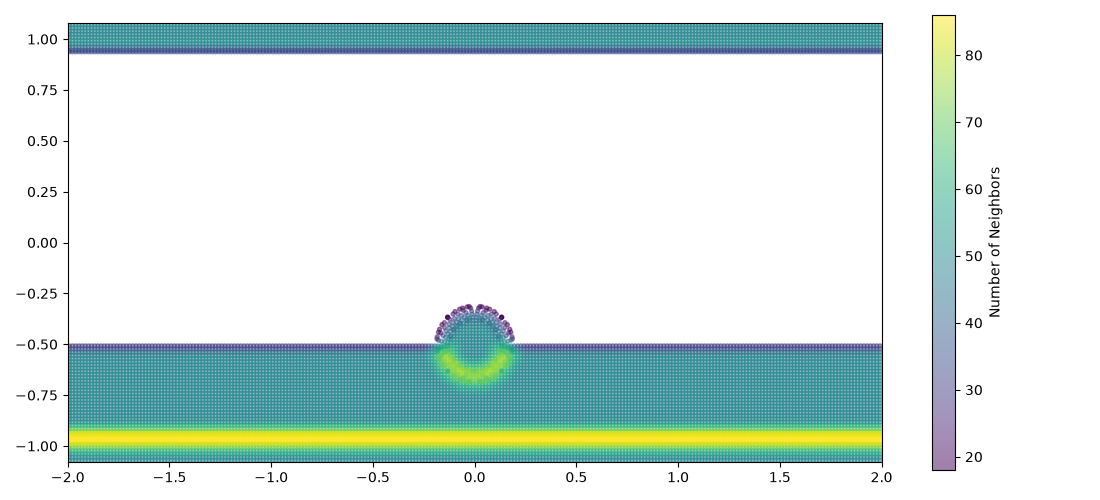

In [14]:
fig, axis = plt.subplots(1, 1, figsize=(11, 5), squeeze=False)
sc = axis[0,0].scatter(runningState.state.positions[:,0].cpu().numpy(), runningState.state.positions[:,1].cpu().numpy(), s=args.markerSize, c=adjacency.numNeighbors.cpu().numpy(), cmap='viridis', alpha=0.5)
fig.colorbar(sc, ax=axis[0,0], label='Number of Neighbors')


for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(domain.min[0].item(), domain.max[0].item())
    ax.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()

In [15]:
from sphWarpCore import buildCompactHashMap
currentState = runningState.state

datastructure = buildCompactHashMap(
    currentState.positions,
    currentState.positions,
    currentState.supports,
    currentState.supports,
    config.domain.periodic,
    config.domain,
    SupportScheme.SuperSymmetric,
    1024
) 
print(datastructure)

CompactHashMap(sortedPositions=tensor([[-1.9922, -1.0703],
        [-1.9766, -1.0703],
        [-1.9609, -1.0703],
        ...,
        [ 1.9609,  1.0703],
        [ 1.9766,  1.0703],
        [ 1.9922,  1.0703]], device='cuda:0'), sortedSupports=tensor([0.0625, 0.0625, 0.0625,  ..., 0.0625, 0.0625, 0.0625], device='cuda:0'), sortIndex=tensor([ 8296,  8297,  8298,  ..., 10853, 10854, 10855], device='cuda:0'), hashTable=tensor([[  0,   1],
        [ -1,   0],
        [ -1,   0],
        ...,
        [775,   1],
        [776,   1],
        [777,   1]], device='cuda:0', dtype=torch.int32), sortedCellTable=tensor([[   0,    0,   16],
        [ 250, 5344,   16],
        [ 239, 5164,   16],
        ...,
        [  33,  536,   16],
        [  22,  356,   16],
        [  11,  180,   16]], device='cuda:0'), qMin=tensor([-2.0000, -1.0781], device='cuda:0'), qMax=tensor([2.0000, 1.0781], device='cuda:0'), hCell=float32(tensor(0.0634, device='cuda:0')), numCells=tensor([63, 34], device='cuda:0', dt

In [16]:
print((datastructure.qMax - datastructure.qMin) / float(datastructure.hCell))

cellx = torch.floor((currentState.positions[:,0] - datastructure.qMin[0]) / float(datastructure.hCell))
celly = torch.floor((currentState.positions[:,1] - datastructure.qMin[1]) / float(datastructure.hCell))

print(cellx.min(), cellx.max())
print(celly.min(), celly.max())

tensor([63.0725, 34.0000], device='cuda:0')
tensor(0., device='cuda:0') tensor(62., device='cuda:0')
tensor(0., device='cuda:0') tensor(33., device='cuda:0')


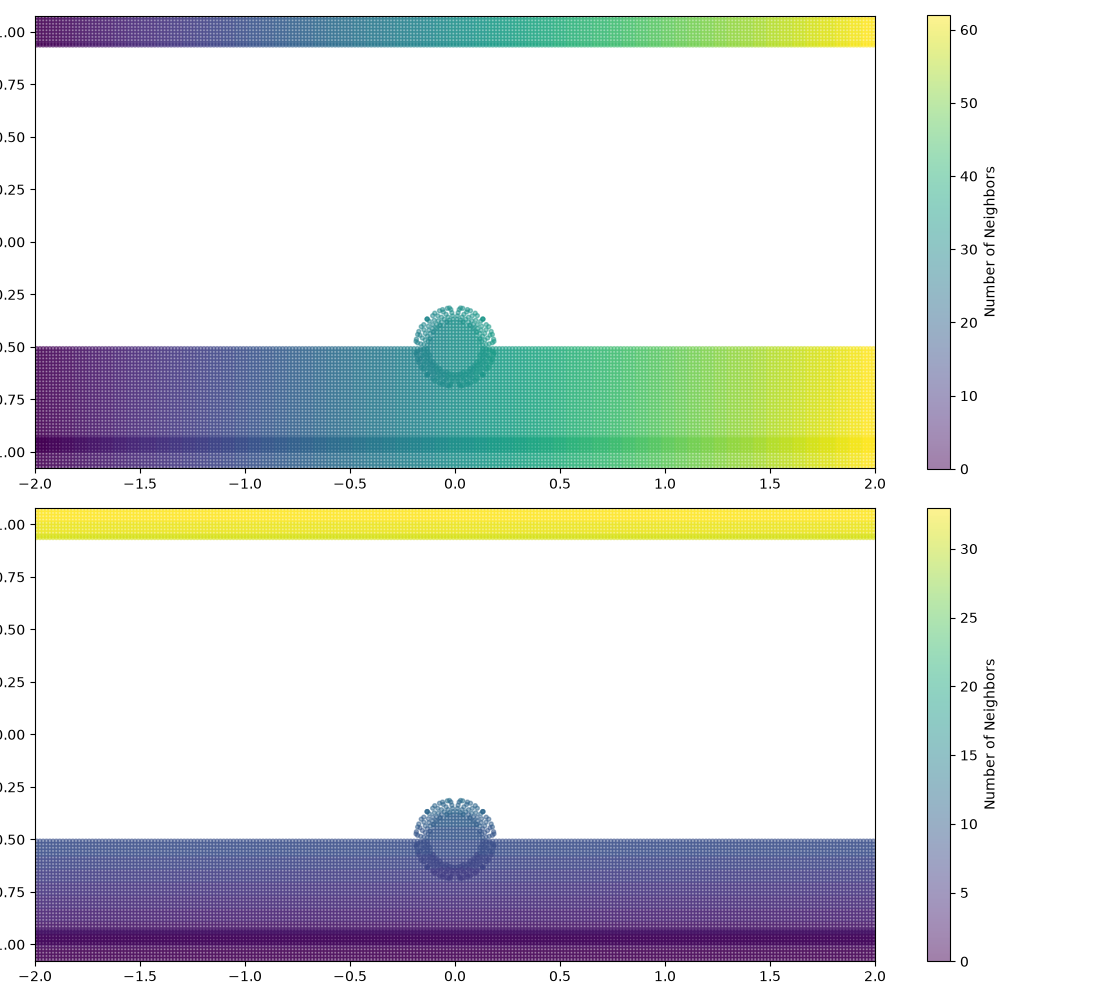

In [17]:
fig, axis = plt.subplots(2, 1, figsize=(11, 10), squeeze=False)
sc = axis[0,0].scatter(runningState.state.positions[:,0].cpu().numpy(), runningState.state.positions[:,1].cpu().numpy(), s=args.markerSize, c=cellx.cpu().numpy(), cmap='viridis', alpha=0.5)
fig.colorbar(sc, ax=axis[0,0], label='Number of Neighbors')

sc = axis[1,0].scatter(runningState.state.positions[:,0].cpu().numpy(), runningState.state.positions[:,1].cpu().numpy(), s=args.markerSize, c=celly.cpu().numpy(), cmap='viridis', alpha=0.5)
fig.colorbar(sc, ax=axis[1,0], label='Number of Neighbors')

for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(domain.min[0].item(), domain.max[0].item())
    ax.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()

In [18]:
schemeConfig.diffusionParams.inviscid = True
schemeConfig.diffusionParams.viscidNu = 0.01

nu = schemeConfig.diffusionParams.viscidNu if schemeConfig.diffusionParams.inviscid == False else alphaToNu(schemeConfig.diffusionParams.inviscidAlpha, schemeConfig.fluid.fixedSoundSpeed, compressibleSystem.state.supports.mean().cpu().item(), config.dim)
alpha = nuToAlpha(schemeConfig.diffusionParams.viscidNu, schemeConfig.fluid.fixedSoundSpeed, compressibleSystem.state.supports.mean().cpu().item(), config.dim) if schemeConfig.diffusionParams.inviscid == False else schemeConfig.diffusionParams.inviscidAlpha

print(f'Using inviscid: {schemeConfig.diffusionParams.inviscid}, nu: {nu:.6g}, alpha: {alpha:.6g}')

u_mag = 1
Re = u_mag / nu * (domain.max[0].cpu().item() - domain.min[0].cpu().item()) / 2
print(f"Reynolds number: {Re:.6g}\nnu: {nu:.6g} (alpha: {alpha:.6g})\nu_mag: {u_mag:.6g}, L: {(domain.max[0].cpu().item() - domain.min[0].cpu().item()) / 2:.6g}")
if alpha < 0.01:
    print(f'Running with a viscosity of alpha < 0.01 may result in unstable simulations.')
nu_limit = alphaToNu(0.01, schemeConfig.fluid.fixedSoundSpeed, compressibleSystem.state.supports.mean().cpu().item(), config.dim)
Re_limit = u_mag / nu_limit * (domain.max[0].cpu().item() - domain.min[0].cpu().item()) / 2
print(f'Reynolds limit based on alpha = 0.01, nu = {nu_limit:.6g}, Re = {Re_limit:.6g}')

Using inviscid: True, nu: 0.00134932, alpha: 0.01
Reynolds number: 1482.23
nu: 0.00134932 (alpha: 0.01)
u_mag: 1, L: 2
Reynolds limit based on alpha = 0.01, nu = 0.00134932, Re = 1482.23


In [23]:

markerSize = args.markerSize
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.velocities,
        "B":runningState.state.densities,
        "C":runningState.state.UIDs
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            mapping = Mapping.L2Norm,
            plotTitle = "velocities",
            plotTitleGap = 0.08,
            boundaryVisualization = VisualizeOptions.Visualize,
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
            # vMin=1e-10
            vMin = 0.0,
            vMax = schemeConfig.fluid.fixedSoundSpeed * 0.1
        ),
        "B": PlottingOptions(
            colorMap = DivergingColorMap.RdBu,
            flipColorMap=True,
            markerSize = markerSize,
            midPoint = 1.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "densities",
            vMin = 0.95,
            vMax = 1.05,
            plotTitleGap = 0.08,
            boundaryVisualization = VisualizeOptions.Visualize,
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        ),
        "C": PlottingOptions(
            colorMap = CyclicColorMap.twilight,
            # flipColorMap=True,
            markerSize = markerSize,
            # midPoint = 1.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "UIDs",
            # vMin = 0.95,
            # vMax = 1.05
            plotTitleGap = 0.08,
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        )
    },
    figTitle = "Taylor Green Vortex",
    mosaic = 'ABC',
    figsize= (args.plotWidth,5),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

plotter.updateTitle(f'Taylor Green Vortex | t = {runningState.t:.4g} | dt = {config.dt:.4g} | particles = {len(runningState.state.positions)}')

imagePath = f'{exportPath}/images'
os.makedirs(imagePath, exist_ok = True)
plotter.export(f'{imagePath}/frame_00000.png', dpi = 300)



NameError: name 'runningState' is not defined

In [24]:
t_limit = 1.28
nSteps = int(t_limit / config.dt)

runningState = compressibleSystem.initializeNewState()
# schemeConfig.rigidBodies[0].linearVelocity = 0.0

kes = []
priorStep = None
for i in (tq := tqdm(range(nSteps), leave = False)):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    result = integrator.function(
        state = runningState,
        f = fn,
        dt = config.dt,  
        config = config,
        schemeConfig = schemeConfig,
        verbose = False,
        # priorStep = priorStep
    )
    kes.append(torch.sum(0.5 * result.state.state.masses * torch.sum(result.state.state.velocities**2, dim=1)))
    # print('max_vel:', torch.linalg.norm(result.state.state.velocities, dim = -1).max())
    end.record()
    torch.cuda.synchronize()
    priorStep = result.stages[-1]
    timing = begin.elapsed_time(end)

    runningState = result.state
    t = runningState.t
    # schemeConfig.rigidBodies[0].linearVelocity = 0.5 * torch.cos(t * np.pi * 2)
    # linearVelocity = 0.5 * torch.cos(t * np.pi * 2)

    currentState = runningState.state
    # print(f'-' * 80)
    # print(f'Fluid density stats: min={currentState.densities[currentState.kinds == 0].min().item()}, max={currentState.densities[currentState.kinds == 0].max().item()}, mean={currentState.densities[currentState.kinds == 0].mean().item()}')
    # print(f'Boundary density stats: min={currentState.densities[currentState.kinds == 1].min().item()}, max={currentState.densities[currentState.kinds == 1].max().item()}, mean={currentState.densities[currentState.kinds == 1].mean().item()}')
    if i % 20 == 0 :
        densities = computeDensities(runningState.state, config, schemeConfig, None)

        plotter.updateQuantities(
            {
                "A": runningState.state.velocities,
                "B": runningState.state.densities,
                "C": runningState.state.UIDs
            },
            newParticleState = runningState.state,
        )
        plotter.export(f'{imagePath}/frame_{i:05d}.png', dpi = 300)
    # break
        
    maxVel = torch.linalg.norm(runningState.state.velocities, dim = -1).max()
    tq.set_description(f"Step {i+1}/{nSteps}, time: {(i+1)*config.dt:8.4g}/{t_limit:8.4g} | max vel: {maxVel:.3g} | iter time: {timing:.3f} ms")
    # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
    # break
    if torch.any(torch.isnan(runningState.state.velocities)):
        print("NaN detected in velocities, stopping simulation.")
        break



  0%|          | 0/2560 [00:00<?, ?it/s]

Module sphWarpCore.radiusSearch.wp_compactHash a87b46c load on device 'cuda:0' took 3.86 ms  (cached)
Module warpSPH.modules.liu.wp_mat b6f4425 load on device 'cuda:0' took 4.38 ms  (cached)
Module sphWarpCore.operations.wp_interpolate 80a3445 load on device 'cuda:0' took 2.78 ms  (cached)
Module sphWarpCore.operations.wp_interpolate 0d95af7 load on device 'cuda:0' took 4.17 ms  (cached)
Module sphWarpCore.renorm.wp_covariance b44d6bf load on device 'cuda:0' took 4.31 ms  (cached)
Module sphWarpCore.operations.wp_gradient c2fad8b load on device 'cuda:0' took 3.53 ms  (cached)
Module warpSPH.modules.surfaceDetection.wp_barecasco 9525f0b load on device 'cuda:0' took 6.88 ms  (cached)
Module warpSPH.modules.surfaceDetection.wp_dilate 9b431c6 load on device 'cuda:0' took 2.28 ms  (cached)
Module warpSPH.modules.deltaSPH.wp_densityDelta b7543ee load on device 'cuda:0' took 3.13 ms  (cached)
Module warpSPH.modules.deltaSPH.wp_viscosityDelta b8b53bf load on device 'cuda:0' took 3.47 ms  (cach

NameError: name 'plotter' is not defined

In [15]:
markerSize = args.markerSize
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.surfaceIndicators,
        "B":runningState.state.surfaceNormals,
        "C":runningState.state.surfaceNormals
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            # mapping = Mapping.L2Norm,
            plotTitle = "velocities",
            plotTitleGap = 0.08,
            boundaryVisualization = VisualizeOptions.Visualize,
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
            # vMin=1e-10
            vMin = 0.0,
            vMax = schemeConfig.fluid.fixedSoundSpeed * 0.1
        ),
        "B": PlottingOptions(
            colorMap = DivergingColorMap.RdBu,
            flipColorMap=True,
            markerSize = markerSize,
            # midPoint = 1.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "densities",
            mapping = Mapping.x,
            # vMin = 0.95,
            # vMax = 1.05,
            plotTitleGap = 0.08,
            boundaryVisualization = VisualizeOptions.Visualize,
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        ),
        "C": PlottingOptions(
            colorMap = DivergingColorMap.RdBu,
            flipColorMap=True,
            # flipColorMap=True,
            markerSize = markerSize,
            # midPoint = 1.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "UIDs",
            mapping = Mapping.y,
            # vMin = 0.95,
            # vMax = 1.05
            plotTitleGap = 0.08,
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        )
    },
    figTitle = "Taylor Green Vortex",
    mosaic = 'ABC',
    figsize= (args.plotWidth,5),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)



RFBOutputContext()

TypeError: 'NoneType' object is not iterable

In [16]:
config.domain.periodic

tensor([True, True], device='cuda:0')

In [17]:
currentSystem = runningState.initializeNewState()
currentState = currentSystem.state
adjacency = currentSystem.adjacency

In [18]:
from sphWarpCore import buildCompactHashMap

datastructure = buildCompactHashMap(
    currentState.positions,
    currentState.positions,
    currentState.supports,
    currentState.supports,
    config.domain.periodic,
    config.domain,
    SupportScheme.SuperSymmetric,
    1024
) 
print(datastructure)

Module sphWarpCore.radiusSearch.wp_compactHash 7d19b25 load on device 'cuda:0' took 2416.66 ms  (compiled)
CompactHashMap(sortedPositions=tensor([[-1.9922, -1.0703],
        [-1.9766, -1.0703],
        [-1.9609, -1.0703],
        ...,
        [ 1.9609,  1.0703],
        [ 1.9766,  1.0703],
        [ 1.9922,  1.0703]], device='cuda:0'), sortedSupports=tensor([0.0625, 0.0625, 0.0625,  ..., 0.0625, 0.0625, 0.0625], device='cuda:0'), sortIndex=tensor([ 8296,  8297,  8298,  ..., 10853, 10854, 10855], device='cuda:0'), hashTable=tensor([[  0,   1],
        [ -1,   0],
        [ -1,   0],
        ...,
        [775,   1],
        [776,   1],
        [777,   1]], device='cuda:0', dtype=torch.int32), sortedCellTable=tensor([[   0,    0,   16],
        [ 253, 5344,   16],
        [ 242, 5164,   16],
        ...,
        [  33,  536,   16],
        [  22,  356,   16],
        [  11,  180,   16]], device='cuda:0'), qMin=tensor([-2.0000, -1.0781], device='cuda:0'), qMax=tensor([2.0000, 1.0781], devi

In [19]:

adjacency = buildVerletList(
    currentState, 
    config.domain, verletScale = 1.0, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = None,
    verbose = False)
currentSystem.adjacency = adjacency

In [20]:

# 2. Compute density if density is none
# with TimedBlock('compute density', use_cuda=True, device=config.device) as tb_density:
with record_function("[warpSPH] - [deltaSPH - 02] - compute density"):
    if currentState.densities is None:
        print("Computing densities...")
        currentState.densities = computeDensities(currentState, config, schemeConfig, adjacency)
# 3. Skipped mDBC density computation since no boundaries are present
# with TimedBlock('compute mDBC density', use_cuda=True, device=config.device) as tb_mdbc:
with record_function("[warpSPH] - [deltaSPH - 03] - compute mDBC density"):
    currentState.densities = computeMdbcDensity(currentState, config, schemeConfig, adjacency)

    
with record_function("[warpSPH] - [deltaSPH - 06] - compute boundary velocities"):
    currentVelocities = currentState.velocities.clone()
    currentState.velocities = computeBoundaryVelocities(currentState, config, schemeConfig, adjacency)

Module warpSPH.modules.liu.wp_mat b6f4425 load on device 'cuda:0' took 5.88 ms  (cached)
Module sphWarpCore.operations.wp_interpolate 80a3445 load on device 'cuda:0' took 7.73 ms  (cached)
Module sphWarpCore.operations.wp_interpolate 0d95af7 load on device 'cuda:0' took 8.75 ms  (cached)


In [21]:
# with TimedBlock('compute EOS', use_cuda=True, device=config.device) as tb_eos:
with record_function("[warpSPH] - [deltaSPH - 05] - compute EOS"):
    currentState.pressures = weaklyCompressibleEOS(currentState, schemeConfig)

In [22]:

with record_function("[warpSPH] - [deltaSPH - 08] - compute surface detection"):
    fs, fsm, n, renormalizationState_, lMin = detectFreeSurface(currentState, config, schemeConfig, schemeConfig.surfaceDetectionConfig, adjacency, returnNormals = True) 
    currentState.surfaceIndicators = (fsm > 0.5).to(torch.int32)
    currentState.surfaceNormals = n
    currentState.surfaceLambdas = lMin

Module sphWarpCore.renorm.wp_covariance b44d6bf load on device 'cuda:0' took 5.02 ms  (cached)
Module sphWarpCore.operations.wp_gradient c2fad8b load on device 'cuda:0' took 4.00 ms  (cached)
Module warpSPH.modules.surfaceDetection.wp_barecasco 9525f0b load on device 'cuda:0' took 6.19 ms  (cached)
Module warpSPH.modules.surfaceDetection.wp_dilate 9b431c6 load on device 'cuda:0' took 2.46 ms  (cached)


In [23]:
n[torch.logical_and(currentState.kinds!=2, currentState.positions[:,1] > 0.75),0]

tensor([-0.7069, -0.5600, -0.2036,  ...,  0.9998,  1.0000,  1.0000],
       device='cuda:0')

In [24]:
maskFluid = torch.logical_and(currentState.kinds==0, currentState.positions[:,1] > 0.75)
currentState.densities[maskFluid]

tensor([], device='cuda:0')

In [25]:
dt = config.dt
#9. Compute gradRho and gradRhoL
# with TimedBlock('compute gradRho', use_cuda=True, device=config.device) as tb_gradRho:
with record_function("[warpSPH] - [deltaSPH - 09] - compute gradRho and gradRhoL"):
    if schemeConfig.diffusionParams.densityDiffusionTerm == DensityDiffusionScheme.denormalized or schemeConfig.diffusionParams.densityDiffusionTerm == DensityDiffusionScheme.denormalizedOnly:
        gradRho = computeGradRho(currentState, config, schemeConfig, adjacency)
    else:
        gradRho = None
# with TimedBlock('compute gradRhoL', use_cuda=True, device=config.device) as tb_gradRhoL:
with record_function("[warpSPH] - [deltaSPH - 09] - compute gradRhoL"):
    if schemeConfig.diffusionParams.densityDiffusionTerm == DensityDiffusionScheme.deltaSPH or schemeConfig.diffusionParams.densityDiffusionTerm == DensityDiffusionScheme.deltaOnly:
        gradRhoL = computeGradRhoL(currentState, config, schemeConfig, adjacency, L = renormalizationState_)
    else:
        gradRhoL = None


# 10. Compute drhodt_diss
# with TimedBlock('compute drhodt_diss', use_cuda=True, device=config.device) as tb_drhodt_diss:
with record_function("[warpSPH] - [deltaSPH - 10] - compute drhodt_diss"):
    drhodt_diss = computeDensityDiffusion(currentState, config, schemeConfig, adjacency, gradRho, gradRhoL)

# 11. Compute dvdt_diss
# with TimedBlock('compute dvdt_diss', use_cuda=True, device=config.device) as tb_dvdt_diss:
with record_function("[warpSPH] - [deltaSPH - 11] - compute dvdt_diss"):
    dvdt_diss = computeVelocityDiffusion(currentState, config, schemeConfig, adjacency)

# 12. Compute drhodt
# with TimedBlock('compute drhodt', use_cuda=True, device=config.device) as tb_drhodt:
with record_function("[warpSPH] - [deltaSPH - 12] - compute drhodt"):
    drhodt = computeMomentum(currentState, config, schemeConfig, adjacency)

# 13. Compute dvdt from pressure
# with TimedBlock('compute dvdt', use_cuda=True, device=config.device) as tb_dvdt:
with record_function("[warpSPH] - [deltaSPH - 13] - compute dvdt from pressure"):
    dvdt_p = computePressureForceSurfaceAware(currentState, config, schemeConfig, adjacency)

# 14. Apply forcing
# with TimedBlock('compute forcing', use_cuda=True, device=config.device) as tb_forcing:
with record_function("[warpSPH] - [deltaSPH - 14] - compute forcing"):
    forcing = computeForcing(currentSystem, config.dt, currentSystem.t, config, schemeConfig)
    dvdt_f = forcing / currentState.masses.view(-1,1)


# 15. Compute gravity
# with TimedBlock('compute gravity', use_cuda=True, device=config.device) as tb_gravity:
with record_function("[warpSPH] - [deltaSPH - 15] - compute gravity"):
    gravity = computeGravity(currentState, config, schemeConfig, adjacency)
    dvdt_g = gravity

# Revert boundary velocity
# with TimedBlock('compute mDBC no-pen shift', use_cuda=True, device=config.device) as tb_nopenshift:
with record_function("[warpSPH] - [deltaSPH - 16] - compute mDBC no-pen shift"):
    nopenshift = computeMdbcNoPenShift(currentState, config, schemeConfig, adjacency)
    dvdt_n = nopenshift / dt
# currentState.velocities = currentVelocities


Module warpSPH.modules.deltaSPH.wp_densityDelta b7543ee load on device 'cuda:0' took 3.27 ms  (cached)
Module warpSPH.modules.deltaSPH.wp_viscosityDelta b8b53bf load on device 'cuda:0' took 5.30 ms  (cached)
Module sphWarpCore.operations.wp_divergence 7616651 load on device 'cuda:0' took 3.94 ms  (cached)
Module warpSPH.modules.pressure.wp_surfaceAware f7cf9cd load on device 'cuda:0' took 3.86 ms  (cached)
Module warpSPH.modules.mdbc.wp_nopenshift 9247db5 load on device 'cuda:0' took 4.49 ms  (cached)


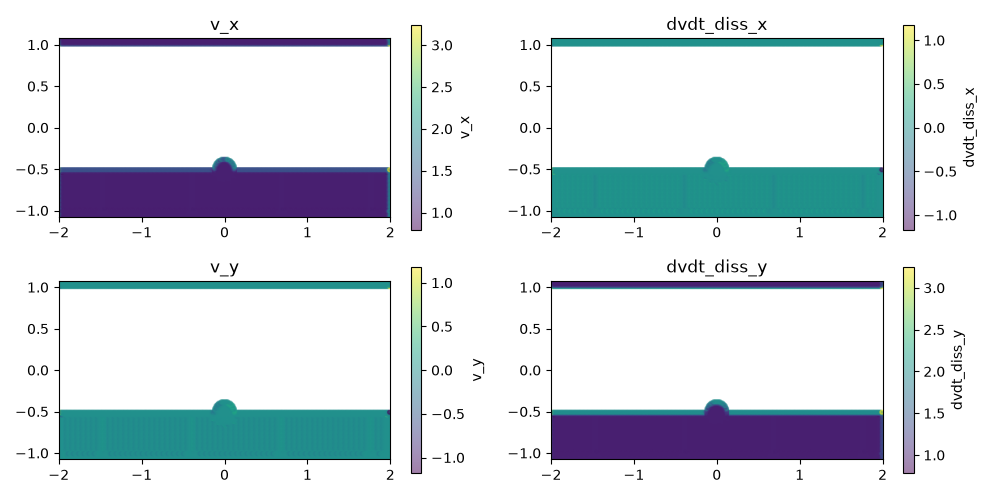

In [26]:
fig, axis = plt.subplots(2, 2, figsize=(10,5), squeeze=False)
maskFluid = torch.logical_and(currentState.kinds==0, currentState.positions[:,1] > 0.75)
mask = maskFluid
# mask = torch.ones_like(maskFluid, dtype=torch.bool)
mask = currentState.kinds != 2
markerSize = 0.1


C = renormalizationState_.renormalizationMatrices

axis[0,0].scatter(currentState.positions[mask,0].cpu().numpy(), currentState.positions[mask,1].cpu().numpy(), s=args.markerSize, c=C[mask,0,0].cpu().numpy(), cmap='viridis', alpha=0.5)#, vmin = -1.0, vmax = 1.0)
fig.colorbar(axis[0,0].collections[0], ax=axis[0,0], label='v_x')
axis[0,0].set_title('v_x')
axis[1,0].scatter(currentState.positions[mask,0].cpu().numpy(), currentState.positions[mask,1].cpu().numpy(), s=args.markerSize, c=C[mask,1,0].cpu().numpy(), cmap='viridis', alpha=0.5)#, vmin = -1.0, vmax = 1.0)
fig.colorbar(axis[1,0].collections[0], ax=axis[1,0], label='v_y')
axis[1,0].set_title('v_y')

axis[0,1].scatter(currentState.positions[mask,0].cpu().numpy(), currentState.positions[mask,1].cpu().numpy(), s=args.markerSize, c=C[mask,0,1].cpu().numpy(), cmap='viridis', alpha=0.5)#, vmin = -1.0, vmax = 1.0)
fig.colorbar(axis[0,1].collections[0], ax=axis[0,1], label='dvdt_diss_x')
axis[0,1].set_title('dvdt_diss_x')
axis[1,1].scatter(currentState.positions[mask,0].cpu().numpy(), currentState.positions[mask,1].cpu().numpy(), s=args.markerSize, c=C[mask,1,1].cpu().numpy(), cmap='viridis', alpha=0.5)#, vmin = -1.0, vmax = 1.0)
fig.colorbar(axis[1,1].collections[0], ax=axis[1,1], label='dvdt_diss_y')
axis[1,1].set_title('dvdt_diss_y')

for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(domain.min[0].item(), domain.max[0].item())
    ax.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()

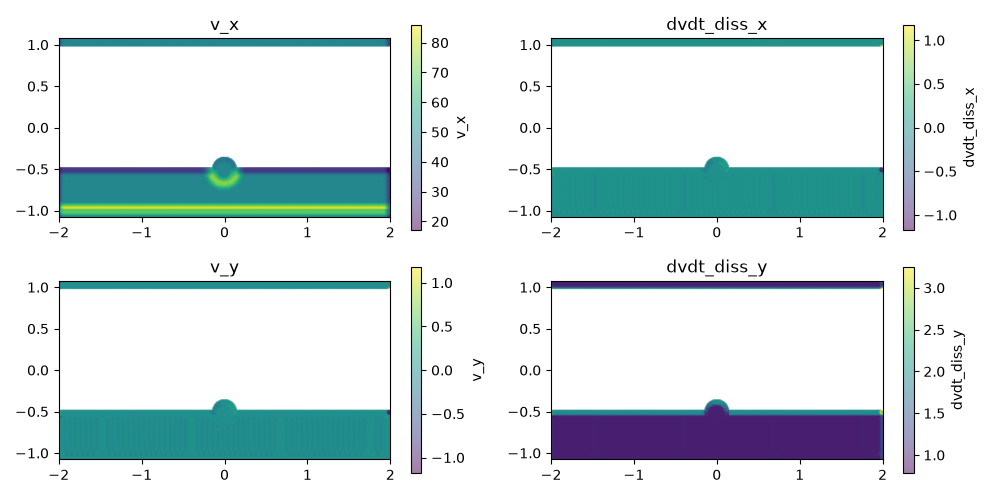

In [27]:
fig, axis = plt.subplots(2, 2, figsize=(10,5), squeeze=False)
maskFluid = torch.logical_and(currentState.kinds==0, currentState.positions[:,1] > 0.75)
mask = maskFluid
# mask = torch.ones_like(maskFluid, dtype=torch.bool)
mask = currentState.kinds != 2
markerSize = 0.1


C = renormalizationState_.renormalizationMatrices

axis[0,0].scatter(currentState.positions[mask,0].cpu().numpy(), currentState.positions[mask,1].cpu().numpy(), s=args.markerSize, c=adjacency.numNeighbors[mask].cpu().numpy(), cmap='viridis', alpha=0.5)#, vmin = -1.0, vmax = 1.0)
fig.colorbar(axis[0,0].collections[0], ax=axis[0,0], label='v_x')
axis[0,0].set_title('v_x')
axis[1,0].scatter(currentState.positions[mask,0].cpu().numpy(), currentState.positions[mask,1].cpu().numpy(), s=args.markerSize, c=C[mask,1,0].cpu().numpy(), cmap='viridis', alpha=0.5)#, vmin = -1.0, vmax = 1.0)
fig.colorbar(axis[1,0].collections[0], ax=axis[1,0], label='v_y')
axis[1,0].set_title('v_y')

axis[0,1].scatter(currentState.positions[mask,0].cpu().numpy(), currentState.positions[mask,1].cpu().numpy(), s=args.markerSize, c=C[mask,0,1].cpu().numpy(), cmap='viridis', alpha=0.5)#, vmin = -1.0, vmax = 1.0)
fig.colorbar(axis[0,1].collections[0], ax=axis[0,1], label='dvdt_diss_x')
axis[0,1].set_title('dvdt_diss_x')
axis[1,1].scatter(currentState.positions[mask,0].cpu().numpy(), currentState.positions[mask,1].cpu().numpy(), s=args.markerSize, c=C[mask,1,1].cpu().numpy(), cmap='viridis', alpha=0.5)#, vmin = -1.0, vmax = 1.0)
fig.colorbar(axis[1,1].collections[0], ax=axis[1,1], label='dvdt_diss_y')
axis[1,1].set_title('dvdt_diss_y')

for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(domain.min[0].item(), domain.max[0].item())
    ax.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()

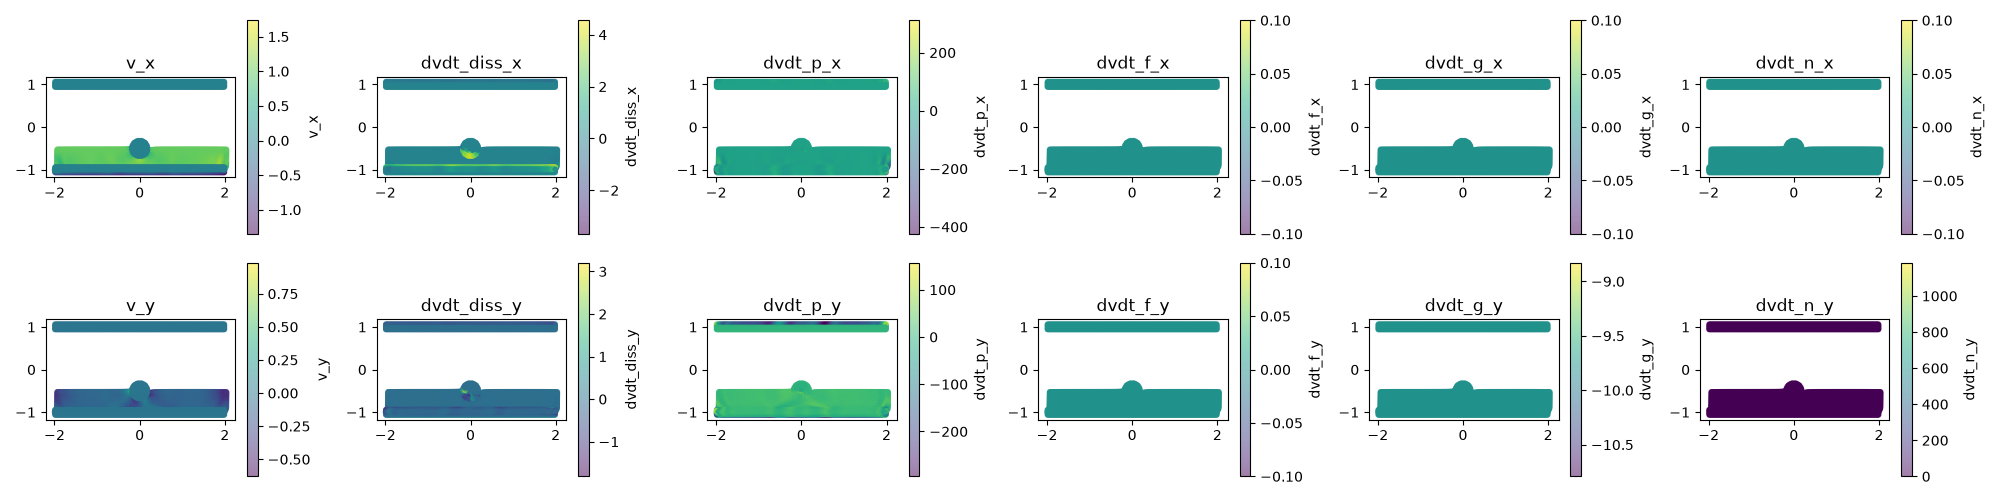

In [ ]:
fig, axis = plt.subplots(2, 6, figsize=(20,5), squeeze=False)
maskFluid = torch.logical_and(currentState.kinds==0, currentState.positions[:,1] > 0.75)
mask = maskFluid
mask = torch.ones_like(maskFluid, dtype=torch.bool)
markerSize = 0.1
axis[0,0].scatter(currentState.positions[mask,0].cpu().numpy(), currentState.positions[mask,1].cpu().numpy(), s=args.markerSize, c=currentState.velocities[mask,0].cpu().numpy(), cmap='viridis', alpha=0.5)
fig.colorbar(axis[0,0].collections[0], ax=axis[0,0], label='v_x')
axis[0,0].set_title('v_x')
axis[1,0].scatter(currentState.positions[mask,0].cpu().numpy(), currentState.positions[mask,1].cpu().numpy(), s=args.markerSize, c=currentState.velocities[mask,1].cpu().numpy(), cmap='viridis', alpha=0.5)
fig.colorbar(axis[1,0].collections[0], ax=axis[1,0], label='v_y')
axis[1,0].set_title('v_y')

axis[0,1].scatter(currentState.positions[mask,0].cpu().numpy(), currentState.positions[mask,1].cpu().numpy(), s=args.markerSize, c=dvdt_diss[mask,0].cpu().numpy(), cmap='viridis', alpha=0.5)
fig.colorbar(axis[0,1].collections[0], ax=axis[0,1], label='dvdt_diss_x')
axis[0,1].set_title('dvdt_diss_x')
axis[1,1].scatter(currentState.positions[mask,0].cpu().numpy(), currentState.positions[mask,1].cpu().numpy(), s=args.markerSize, c=dvdt_diss[mask,1].cpu().numpy(), cmap='viridis', alpha=0.5)
fig.colorbar(axis[1,1].collections[0], ax=axis[1,1], label='dvdt_diss_y')
axis[1,1].set_title('dvdt_diss_y')

axis[0,2].scatter(currentState.positions[mask,0].cpu().numpy(), currentState.positions[mask,1].cpu().numpy(), s=args.markerSize, c=dvdt_p[mask,0].cpu().numpy(), cmap='viridis', alpha=0.5)
fig.colorbar(axis[0,2].collections[0], ax=axis[0,2], label='dvdt_p_x')
axis[0,2].set_title('dvdt_p_x')
axis[1,2].scatter(currentState.positions[mask,0].cpu().numpy(), currentState.positions[mask,1].cpu().numpy(), s=args.markerSize, c=dvdt_p[mask,1].cpu().numpy(), cmap='viridis', alpha=0.5)
fig.colorbar(axis[1,2].collections[0], ax=axis[1,2], label='dvdt_p_y')
axis[1,2].set_title('dvdt_p_y')

axis[0,3].scatter(currentState.positions[mask,0].cpu().numpy(), currentState.positions[mask,1].cpu().numpy(), s=args.markerSize, c=dvdt_f[mask,0].cpu().numpy(), cmap='viridis', alpha=0.5)
fig.colorbar(axis[0,3].collections[0], ax=axis[0,3], label='dvdt_f_x')
axis[0,3].set_title('dvdt_f_x')
axis[1,3].scatter(currentState.positions[mask,0].cpu().numpy(), currentState.positions[mask,1].cpu().numpy(), s=args.markerSize, c=dvdt_f[mask,1].cpu().numpy(), cmap='viridis', alpha=0.5)
fig.colorbar(axis[1,3].collections[0], ax=axis[1,3], label='dvdt_f_y')
axis[1,3].set_title('dvdt_f_y')

axis[0,4].scatter(currentState.positions[mask,0].cpu().numpy(), currentState.positions[mask,1].cpu().numpy(), s=args.markerSize, c=dvdt_g[mask,0].cpu().numpy(), cmap='viridis', alpha=0.5)
fig.colorbar(axis[0,4].collections[0], ax=axis[0,4], label='dvdt_g_x')
axis[0,4].set_title('dvdt_g_x')
axis[1,4].scatter(currentState.positions[mask,0].cpu().numpy(), currentState.positions[mask,1].cpu().numpy(), s=args.markerSize, c=dvdt_g[mask,1].cpu().numpy(), cmap='viridis', alpha=0.5)
fig.colorbar(axis[1,4].collections[0], ax=axis[1,4], label='dvdt_g_y')
axis[1,4].set_title('dvdt_g_y')

axis[0,5].scatter(currentState.positions[mask,0].cpu().numpy(), currentState.positions[mask,1].cpu().numpy(), s=args.markerSize, c=dvdt_n[mask,0].cpu().numpy(), cmap='viridis', alpha=0.5)
fig.colorbar(axis[0,5].collections[0], ax=axis[0,5], label='dvdt_n_x')
axis[0,5].set_title('dvdt_n_x')
axis[1,5].scatter(currentState.positions[mask,0].cpu().numpy(), currentState.positions[mask,1].cpu().numpy(), s=args.markerSize, c=dvdt_n[mask,1].cpu().numpy(), cmap='viridis', alpha=0.5)
fig.colorbar(axis[1,5].collections[0], ax=axis[1,5], label='dvdt_n_y')
axis[1,5].set_title('dvdt_n_y')

for ax in axis.flatten():
    ax.set_aspect('equal')
    # ax.set_xlim(domain.min[0].item(), domain.max[0].item())
    # ax.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()

In [ ]:
markerSize = args.markerSize
plotter = visualize(
    particleState = currentState,
    domain = config.domain,
    quantities = {
        "A": fs,
        "B": n,
        "C": n
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            # mapping = Mapping.L2Norm,
            plotTitle = "velocities",
            plotTitleGap = 0.08,
            boundaryVisualization = VisualizeOptions.Visualize,
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
            # vMin=1e-10
            vMin = 0.0,
            vMax = schemeConfig.fluid.fixedSoundSpeed * 0.1
        ),
        "B": PlottingOptions(
            colorMap = DivergingColorMap.RdBu,
            flipColorMap=True,
            markerSize = markerSize,
            # midPoint = 1.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "densities",
            mapping = Mapping.x,
            # vMin = 0.95,
            # vMax = 1.05,
            plotTitleGap = 0.08,
            fluidVisualization = VisualizeOptions.Visualize,
            boundaryVisualization = VisualizeOptions.Visualize,
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        ),
        "C": PlottingOptions(
            colorMap = DivergingColorMap.RdBu,
            flipColorMap=True,
            # flipColorMap=True,
            markerSize = markerSize,
            # midPoint = 1.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "UIDs",
            mapping = Mapping.y,
            # vMin = 0.95,
            # vMax = 1.05
            plotTitleGap = 0.08,
            fluidVisualization = VisualizeOptions.Visualize,
            boundaryVisualization = VisualizeOptions.Visualize,
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        )
    },
    figTitle = "Taylor Green Vortex",
    mosaic = 'ABC',
    figsize= (args.plotWidth,5),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)



RFBOutputContext()

In [ ]:
# exportSimulationSystem(exportPath, f'finalState', scheme, runningState, exportAdjacency = False, stages = result.stages, exportStagesAdjacency = True, extraData = dict(**extraData, **{
#     'kineticEnergy': kineticEnergy,
#     'thermalEnergy': thermalEnergy,
#     'totalEnergy': totalEnergy,
#     'frame_num': i,
# }))

In [ ]:
densities = computeDensities(runningState.state, config, schemeConfig, None)

markerSize = 4
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.surfaceIndicators,
        "B":densities,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "velocities",
            plotTitleGap = 0.08,
            # boundaryVisualization= VisualizeOptions.Visualize,
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
            # vMin=0,
            # vMax=1.0
        ),
        "B": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            # colorMap = UniformColorMap.viridis,
            # flipColorMap=True,
            markerSize = markerSize,
            # midPoint = 1.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "UIDs",
            boundaryVisualization= VisualizeOptions.Hide,
            fluidVisualization= VisualizeOptions.Visualize,
            plotTitleGap = 0.08,
            # vMin = 0.99,
            # vMax = 1.01
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'AB',
    figsize= (16,5),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)


RFBOutputContext()

TypeError: 'NoneType' object is not iterable

In [ ]:
ffmpeg_cmd = "ffmpeg -y -loglevel error -hide_banner -framerate 50 -f image2 -pattern_type glob -i 'frame_*.png' -c:v libx264 -pix_fmt yuv420p -b:v 10M output.mp4"
subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4  -vf "fps=50,scale=540:-1:flags=lanczos,palettegen" palette.png'
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4 -i palette.png -filter_complex "fps=25,scale=540:-1:flags=lanczos[x];[x][1:v]paletteuse" out.gif'
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)

# # now copy the output.mp4 and out.gif to the parent directory for easier access
shutil.copy(f'{imagePath}/output.mp4', f'{exportPath}/output.mp4')
# shutil.copy(f'{imagePath}/out.gif', f'{exportPath}/out.gif');

'export/damBreakObstacle/output.mp4'

We can run a convergence test to see how the viscosity scales as well:

In [ ]:
nu_tests = np.logspace(-1, -5, base=10, num=10)
test_data = []

for nu in tqdm(nu_tests, desc="Testing viscosities", leave=False):
    t_limit = 2.0
    nSteps = int(t_limit / config.dt)

    runningState = compressibleSystem.initializeNewState()
    schemeConfig.diffusionParams.viscidNu = nu

    kes = []
    priorStep = None
    for i in (tq := tqdm(range(nSteps), leave = False)):
        begin = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)
        begin.record()
        result = integrator.function(
            state = runningState,
            f = fn,
            dt = config.dt,  
            config = config,
            schemeConfig = schemeConfig,
            verbose = False,
            priorStep = priorStep
        )
        kes.append(torch.sum(0.5 * result.state.state.masses * torch.sum(result.state.state.velocities**2, dim=1)))
        # print('max_vel:', torch.linalg.norm(result.state.state.velocities, dim = -1).max())
        end.record()
        torch.cuda.synchronize()
        priorStep = result.stages[-1]
        timing = begin.elapsed_time(end)

        runningState = result.state

        if i % 60 == 0 and i > 0:
            plotter.updateQuantities(
                {
                    "A": runningState.state.velocities,
                    "B": runningState.state.densities,
                },
                newParticleState = runningState.state,
            )
            
        maxVel = torch.linalg.norm(runningState.state.velocities, dim = -1).max()
        tq.set_description(f"Step {i+1}/{nSteps}, time: {(i+1)*config.dt:8.4g}/{t_limit:8.4g} | max vel: {maxVel:.3g} | iter time: {timing:.3f} ms")
        # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
        # break
        if torch.any(torch.isnan(runningState.state.velocities)):
            print("NaN detected in velocities, stopping simulation.")
            breakts = np.arange(len(kes)) * config.dt.cpu().item()
    kineticEnergy = np.array([ke.cpu().item() for ke in kes])
    E_k0 = kineticEnergy[0]

    # Fit an effective viscosity from d/dt log(E_k) = -4 * (ktgv**2) * nu_eff
    mask = (ts > 0) & (kineticEnergy > 0)
    slope = np.polyfit(ts[mask], np.log(kineticEnergy[mask] / E_k0), 1)[0]
    nu_eff = -slope / (4 * ktgv**2)

    test_data.append({
        'nu': nu,
        'nu_eff': nu_eff,
        'nu_diff': abs(nu_eff - nu),
        'nu_rel_diff': abs(nu_eff - nu) / nu,
        'E_k0': E_k0,
        'kineticEnergy': kineticEnergy,
        'ts': ts,
    })


Testing viscosities:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

...

  0%|          | 0/1999 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

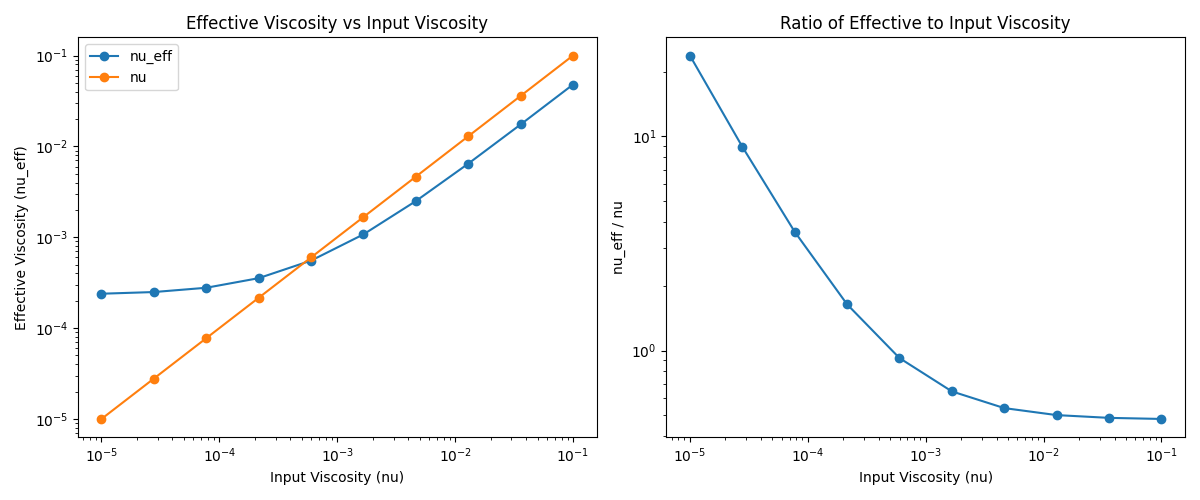

In [ ]:
fig, axis = plt.subplots(1, 2, figsize=(12, 5), squeeze=False)

nus = np.array([data['nu'] for data in test_data])
nu_effs = np.array([data['nu_eff'] for data in test_data])
axis[0,0].loglog(nus, nu_effs, marker='o', label='nu_eff')
axis[0,0].loglog(nus, nus, marker='o', label='nu')
axis[0,0].set_xlabel('Input Viscosity (nu)')
axis[0,0].set_ylabel('Effective Viscosity (nu_eff)')
axis[0,0].set_title('Effective Viscosity vs Input Viscosity')
axis[0,0].legend()

axis[0,1].loglog(nus, nu_effs / nus, marker='o')
axis[0,1].set_xlabel('Input Viscosity (nu)')
axis[0,1].set_ylabel('nu_eff / nu')
axis[0,1].set_title('Ratio of Effective to Input Viscosity')

fig.tight_layout()

fig.savefig('nu_eff_vs_nu.png', dpi=300)
